# Data Loader

Load and flatten the param sweep JSON files into a tidy table.

In [54]:
from pathlib import Path
import json
import re
from datetime import datetime
import numpy as np
import scienceplots
import matplotlib.pyplot as plt
plt.style.use('science')

%config InlineBackend.figure_format = "retina"
%config InlineBackend.figure_format = "png"
%config InlineBackend.print_figure_kwargs = {"dpi": 200}


BASE_DIR = Path("/u/halle/rsim/home_at/projects/Bachelorarbeit/binpacking/data_analysis/non_binpacking_settings/param_sweep")

if not BASE_DIR.exists():
    raise FileNotFoundError(f"BASE_DIR not found: {BASE_DIR}")

FILENAME_RE = re.compile(r"^(?P<kind>[^_]+)_(?P<label>.+)_(?P<ts>\d{8}_\d{6})\.json$")


def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def split_family_variant(group: str):
    if not group:
        return None, None
    parts = group.split("_", 1)
    family = parts[0]
    variant = parts[1] if len(parts) > 1 else None
    return family, variant


def parse_sweep_name(name: str) -> dict:
    prefix = name
    off_pct = None
    on_pct = None
    if "_off" in name and "_on" in name:
        prefix, rest = name.split("_off", 1)
        off_str, on_str = rest.split("_on", 1)
        try:
            off_pct = int(off_str)
            on_pct = int(on_str)
        except ValueError:
            off_pct = None
            on_pct = None
    family, variant = split_family_variant(prefix)
    return {
        "sweep": name,
        "sweep_group": prefix,
        "family": family,
        "variant": variant,
        "off_pct": off_pct,
        "on_pct": on_pct,
    }


def parse_filename(path: Path) -> dict:
    m = FILENAME_RE.match(path.name)
    if not m:
        return {"kind": None, "label": None, "run_id": None, "run_dt": None}
    run_id = m.group("ts")
    try:
        run_dt = datetime.strptime(run_id, "%Y%m%d_%H%M%S")
    except ValueError:
        run_dt = None
    return {
        "kind": m.group("kind"),
        "label": m.group("label"),
        "run_id": run_id,
        "run_dt": run_dt,
    }


def split_label(label: str):
    if not label:
        return None, None
    if "+" in label:
        return label.split("+", 1)
    return label, None


def flatten_record(data: dict, path: Path) -> dict:
    agg = data.get("aggregate", {})
    problem = data.get("problem", {})
    rel = path.relative_to(BASE_DIR)
    sweep_meta = parse_sweep_name(rel.parts[0]) if rel.parts else {}
    name_meta = parse_filename(path)
    pipeline = data.get("pipeline") or name_meta.get("label")
    offline_short, online_short = split_label(pipeline)
    return {
        "file": path.name,
        "path": str(path),
        **sweep_meta,
        **name_meta,
        "scenario": data.get("scenario"),
        "scenario_description": data.get("scenario_description"),
        "pipeline": pipeline,
        "offline_solver": data.get("offline_solver"),
        "online_policy": data.get("online_policy"),
        "offline_short": offline_short,
        "online_short": online_short,
        "seed_count": data.get("seed_count"),
        "per_seed": data.get("per_seed"),
        "total_objective_mean": data.get("total_objective_mean", agg.get("total_objective_mean")),
        "offline_objective_mean": agg.get("offline_objective_mean"),
        "online_objective_mean": agg.get("online_objective_mean"),
        "offline_runtime_mean": agg.get("offline_runtime_mean"),
        "online_runtime_mean": agg.get("online_runtime_mean"),
        "runtime_mean": agg.get("runtime_mean"),
        "offline_failures": agg.get("offline_failures"),
        "online_failures": agg.get("online_failures"),
        "failures": agg.get("failures"),
        "N": problem.get("N"),
        "M_off": problem.get("M_off"),
        "M_on": problem.get("M_on"),
        "dimensions": problem.get("dimensions"),
    }


def load_results(base_dir: Path = BASE_DIR):
    records = []
    for path in sorted(base_dir.rglob("*.json")):
        records.append(flatten_record(read_json(path), path))
    return records


records = load_results()
len(records)


123

In [55]:
try:
    import pandas as pd

    df = pd.DataFrame(records)
    if df.empty:
        df_eval = None
        df_opt = None
        df_per_seed = None
        print("No records loaded. Check BASE_DIR or records.")
    else:
        offline_map = {
            "cabfd": "CaBfd",
            "util": "UtilDecr",
            "binpacking_milp": "MILP",
            "full_horizon": "Benchmark",
        }
        online_map = {
            "primal_dual": "PrimalDualMILP",
            "sim_base": "SimBase",
            "dynamic_learning": "DL",
            "cost_best_fit": "CaBf",
            "rolling_horizon_milp": "RollingMILP",
            "sim_dual":"SimDual"
        }

        def pretty_pipeline(label):
            if not isinstance(label, str) or not label:
                return label
            if "+" in label:
                off_raw, on_raw = (part.strip() for part in label.split("+", 1))
                off_name = offline_map.get(off_raw, off_raw)
                on_name = online_map.get(on_raw, on_raw)
                return f"{off_name} + {on_name}"
            return offline_map.get(label, label)

        df["offline_short_raw"] = df["offline_short"]
        df["online_short_raw"] = df["online_short"]
        df["pipeline_raw"] = df["pipeline"]

        df["offline_short"] = df["offline_short"].map(offline_map).fillna(df["offline_short"])
        df["online_short"] = df["online_short"].map(online_map).fillna(df["online_short"])
        df["pipeline"] = df["pipeline"].apply(pretty_pipeline)

        df_per_seed = None
        if "per_seed" in df.columns:
            df_seed = df[df["per_seed"].notna()].copy()
            if not df_seed.empty:
                df_seed = df_seed.explode("per_seed").reset_index(drop=True)
                seed_cols = pd.json_normalize(df_seed["per_seed"])
                df_seed = df_seed.drop(columns=["per_seed"]).reset_index(drop=True)
                df_seed = pd.concat([df_seed, seed_cols], axis=1)
                df_seed["offline_short"] = (
                    df_seed["offline_short"].map(offline_map).fillna(df_seed["offline_short"])
                )
                df_seed["online_short"] = (
                    df_seed["online_short"].map(online_map).fillna(df_seed["online_short"])
                )
                df_seed["pipeline"] = df_seed["pipeline"].apply(pretty_pipeline)
                df_per_seed = df_seed

        df_eval = df[df["kind"] == "eval"].copy()
        df_opt = df[df["kind"] == "optimal"].copy()
    df.head()
except ImportError:
    df = None
    df_eval = None
    df_opt = None
    df_per_seed = None


In [56]:
if df_eval is not None and df_opt is not None:
    df_eval_completed = df_eval[
        (df_eval["offline_failures"].fillna(0) == 0)
        & (df_eval["online_failures"].fillna(0) == 0)
    ].copy()

    df_opt_key = df_opt[["sweep", "run_id", "scenario", "total_objective_mean"]].rename(
        columns={"total_objective_mean": "optimal_objective_mean"}
    )
    df_ratio_base = df_eval_completed.merge(df_opt_key, on=["sweep", "run_id", "scenario"], how="left")

    keep_base = ["family", "variant", "sweep", "off_pct", "on_pct"]

    df_ratio_offline = df_ratio_base[keep_base + ["offline_short", "offline_objective_mean", "optimal_objective_mean"]].rename(
        columns={
            "offline_short": "algorithm",
            "offline_objective_mean": "objective_mean",
        }
    )
    df_ratio_offline["competitive_ratio"] = (
        df_ratio_offline["objective_mean"] / df_ratio_offline["optimal_objective_mean"]
    )

    df_ratio_online = df_ratio_base[keep_base + ["online_short", "online_objective_mean", "optimal_objective_mean"]].rename(
        columns={
            "online_short": "algorithm",
            "online_objective_mean": "objective_mean",
        }
    )
    df_ratio_online["competitive_ratio"] = (
        df_ratio_online["objective_mean"] / df_ratio_online["optimal_objective_mean"]
    )

    df_ratio_hybrid = df_ratio_base[keep_base + ["pipeline", "total_objective_mean", "optimal_objective_mean"]].rename(
        columns={
            "pipeline": "algorithm",
            "total_objective_mean": "objective_mean",
        }
    )
    df_ratio_hybrid["competitive_ratio"] = (
        df_ratio_hybrid["objective_mean"] / df_ratio_hybrid["optimal_objective_mean"]
    )
else:
    df_ratio_offline = None
    df_ratio_online = None
    df_ratio_hybrid = None


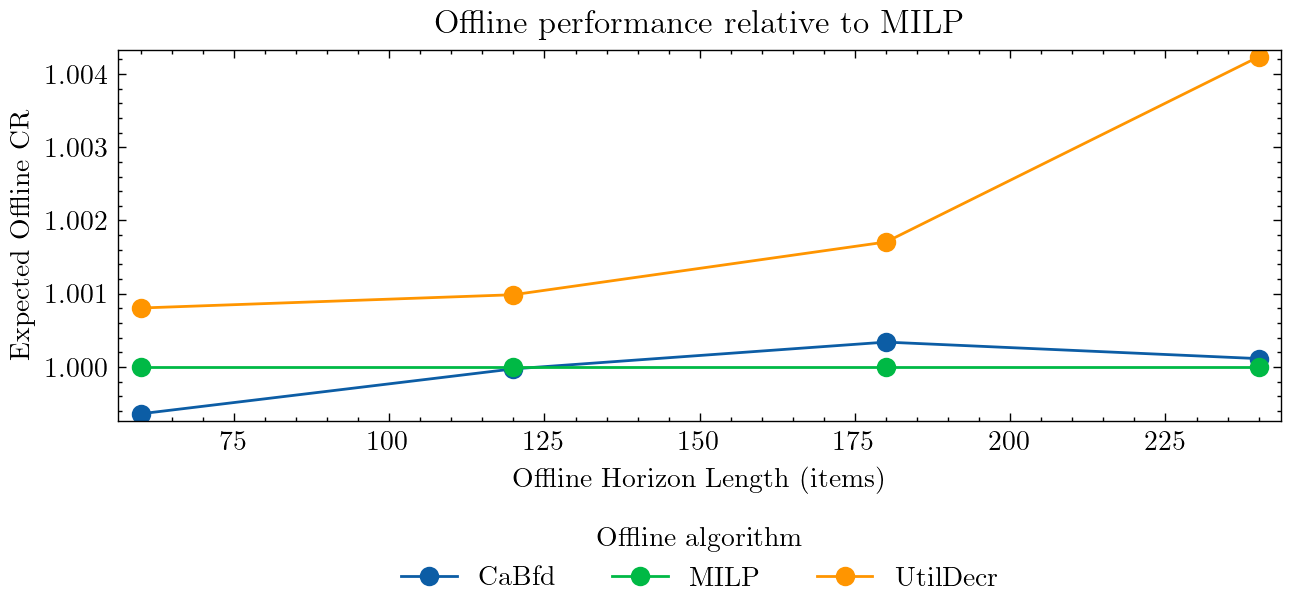

In [57]:
if df_eval is not None:
    df_offline_plot = df_eval[
        ["M_off", "offline_short", "offline_objective_mean"]
    ].copy()
    df_offline_plot = df_offline_plot[df_offline_plot["M_off"].notna()]
    df_offline_plot = df_offline_plot[df_offline_plot["M_off"].gt(0)]
    df_offline_plot = df_offline_plot[df_offline_plot["offline_objective_mean"].notna()]

    grouped = (
        df_offline_plot.groupby(["M_off", "offline_short"], dropna=False)
        .agg(expected_obj=("offline_objective_mean", "mean"))
        .reset_index()
    )

    df_milp = grouped[grouped["offline_short"] == "MILP"][
        ["M_off", "expected_obj"]
    ].rename(columns={"expected_obj": "milp_obj"})
    df_rel = grouped.merge(df_milp, on="M_off", how="left")
    df_rel = df_rel[df_rel["milp_obj"].notna()]
    df_rel["relative_obj"] = df_rel["expected_obj"] / df_rel["milp_obj"]

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    df_rel["offline_short"] = pd.Categorical(
        df_rel["offline_short"], categories=offline_order, ordered=True
    )
    df_rel = df_rel.sort_values(["offline_short", "M_off"])

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    for algo in offline_order:
        df_algo = df_rel[df_rel["offline_short"] == algo]
        if df_algo.empty:
            continue
        ax.plot(
            df_algo["M_off"],
            df_algo["relative_obj"],
            marker="o",
            label=algo,
        )

    #ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Offline performance relative to MILP")
    ax.set_xlabel("Offline Horizon Length (items)")
    ax.set_ylabel("Expected Offline CR")

    y_min = df_rel["relative_obj"].min()
    y_max = df_rel["relative_obj"].max()
    if pd.isna(y_min) or pd.isna(y_max):
        y_min, y_max = 0.0, 1.0
    y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    x_min = df_rel["M_off"].min()
    x_max = df_rel["M_off"].max()
    if pd.notna(x_min) and pd.notna(x_max):
        x_pad = 0.02 * (x_max - x_min) if x_max > x_min else 1
        ax.set_xlim(x_min - x_pad, x_max + x_pad)

    ncol = max(1, df_rel["offline_short"].nunique())
    ax.legend(
        title="Offline algorithm",
        ncol=ncol,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
    )
    fig.subplots_adjust(bottom=0.3)


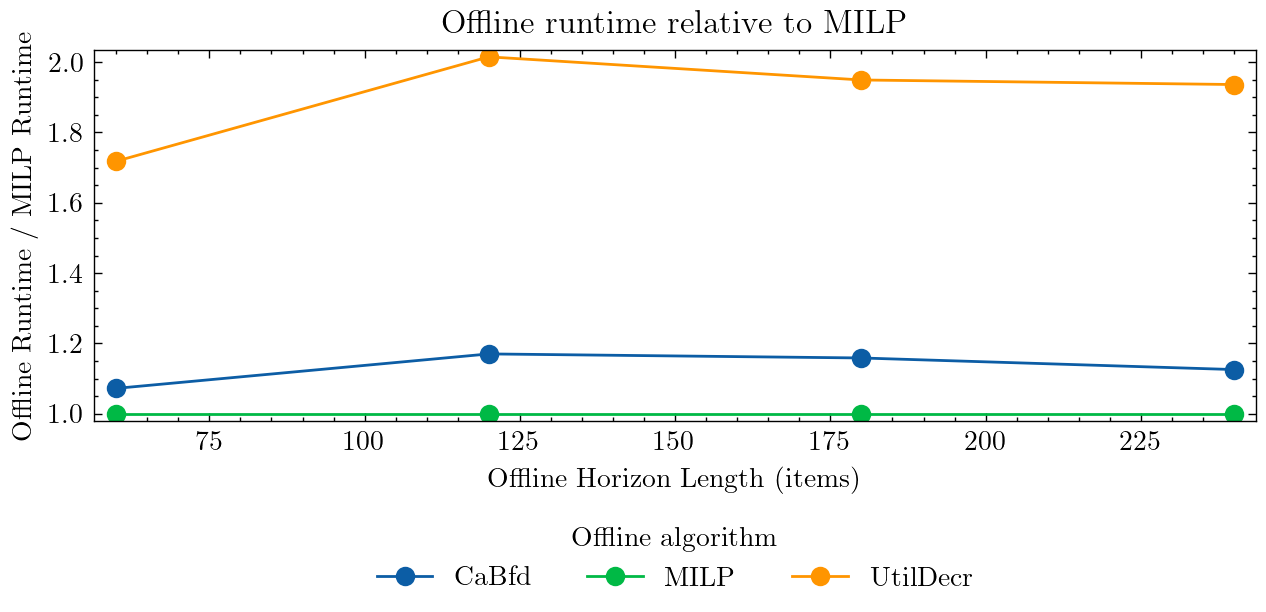

In [58]:
if df_eval is not None:
    df_runtime_plot = df_eval[
        ["M_off", "offline_short", "offline_runtime_mean"]
    ].copy()
    df_runtime_plot = df_runtime_plot[df_runtime_plot["M_off"].notna()]
    df_runtime_plot = df_runtime_plot[df_runtime_plot["M_off"].gt(0)]
    df_runtime_plot = df_runtime_plot[df_runtime_plot["offline_runtime_mean"].notna()]

    grouped = (
        df_runtime_plot.groupby(["M_off", "offline_short"], dropna=False)
        .agg(expected_runtime=("offline_runtime_mean", "mean"))
        .reset_index()
    )

    df_milp = grouped[grouped["offline_short"] == "MILP"][
        ["M_off", "expected_runtime"]
    ].rename(columns={"expected_runtime": "milp_runtime"})
    df_rel = grouped.merge(df_milp, on="M_off", how="left")
    df_rel = df_rel[df_rel["milp_runtime"].notna()]
    df_rel = df_rel[df_rel["milp_runtime"].gt(0)]
    df_rel["relative_runtime"] = df_rel["expected_runtime"] / df_rel["milp_runtime"]

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    df_rel["offline_short"] = pd.Categorical(
        df_rel["offline_short"], categories=offline_order, ordered=True
    )
    df_rel = df_rel.sort_values(["offline_short", "M_off"])

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    for algo in offline_order:
        df_algo = df_rel[df_rel["offline_short"] == algo]
        if df_algo.empty:
            continue
        ax.plot(
            df_algo["M_off"],
            df_algo["relative_runtime"],
            marker="o",
            label=algo,
        )

    #ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Offline runtime relative to MILP")
    ax.set_xlabel("Offline Horizon Length (items)")
    ax.set_ylabel("Offline Runtime / MILP Runtime")

    y_min = df_rel["relative_runtime"].min()
    y_max = df_rel["relative_runtime"].max()
    if pd.isna(y_min) or pd.isna(y_max):
        y_min, y_max = 0.0, 1.0
    y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    x_min = df_rel["M_off"].min()
    x_max = df_rel["M_off"].max()
    if pd.notna(x_min) and pd.notna(x_max):
        x_pad = 0.02 * (x_max - x_min) if x_max > x_min else 1
        ax.set_xlim(x_min - x_pad, x_max + x_pad)

    ncol = max(1, df_rel["offline_short"].nunique())
    ax.legend(
        title="Offline algorithm",
        ncol=ncol,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
    )
    fig.subplots_adjust(bottom=0.3)


<>:80: SyntaxWarning: invalid escape sequence '\%'
<>:80: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_44343/3835889811.py:80: SyntaxWarning: invalid escape sequence '\%'
  ax_fail.set_ylabel("Fail rate (\%)")


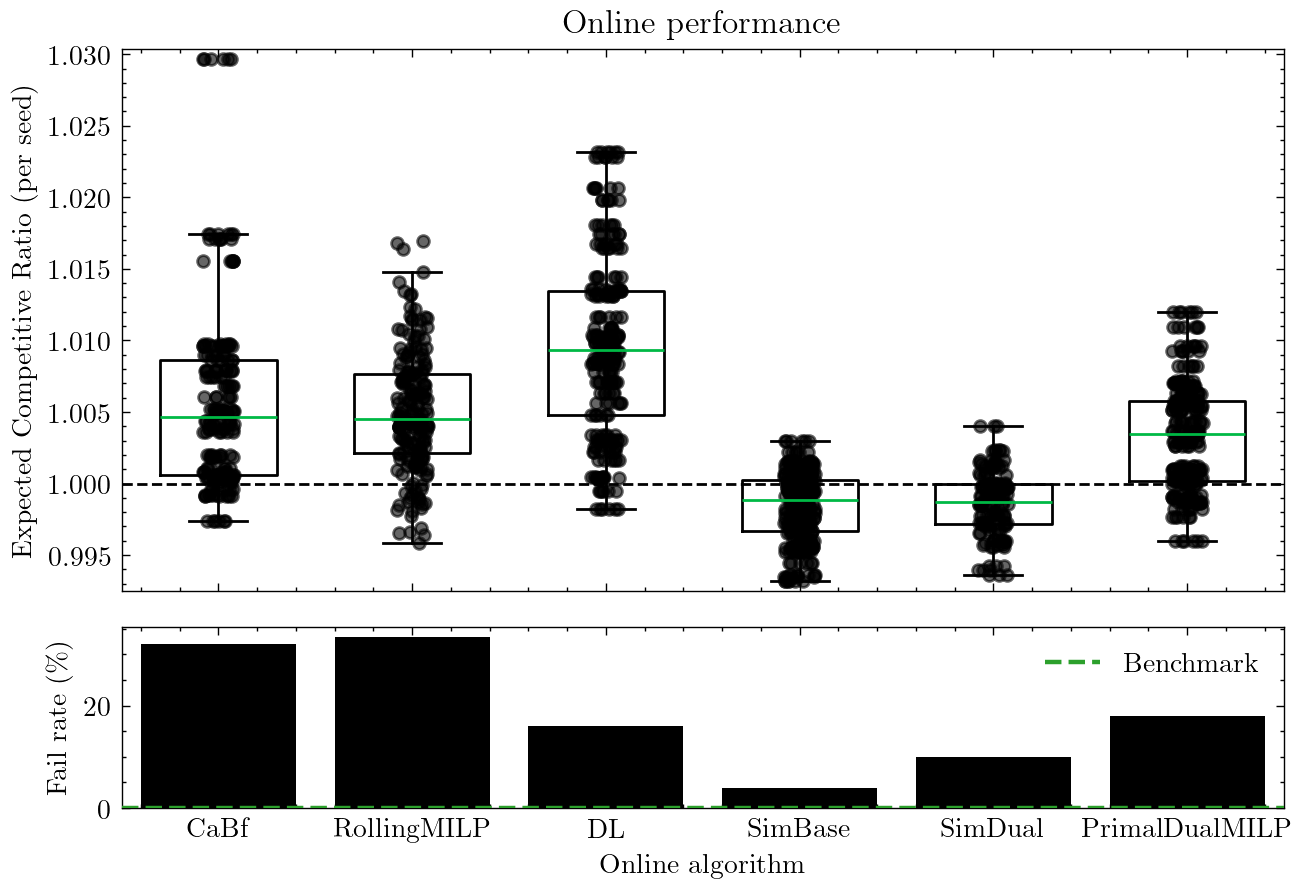

In [59]:
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    df_online_all = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    df_online_success = df_online_all[
        ~df_online_all["offline_status"].isin(offline_fail_statuses)
        & ~df_online_all["online_status"].isin(online_fail_statuses)
    ].copy()

    df_opt_all = df_per_seed[(df_per_seed["kind"] == "optimal") & (df_per_seed["M_off"] == 0)].copy()
    df_opt_success = df_opt_all[~df_opt_all["status"].isin(offline_fail_statuses)].copy()
    df_opt_success = df_opt_success.rename(columns={"total_objective": "optimal_objective"})

    df_join = df_online_success.merge(
        df_opt_success[["sweep", "run_id", "scenario", "seed", "optimal_objective"]],
        on=["sweep", "run_id", "scenario", "seed"],
        how="left",
    )
    df_join = df_join[df_join["optimal_objective"].notna()]
    df_join = df_join[df_join["online_objective"].notna()]
    df_join["competitive_ratio"] = df_join["online_objective"] / df_join["optimal_objective"]

    online_order = ["CaBf", "RollingMILP", "DL", "SimBase","SimDual", "PrimalDualMILP"]
    df_join["online_short"] = pd.Categorical(
        df_join["online_short"], categories=online_order, ordered=True
    )
    df_join = df_join.sort_values(["online_short", "seed"])

    data = []
    labels = []
    for algo in online_order:
        vals = df_join[df_join["online_short"] == algo]["competitive_ratio"].dropna().values
        if len(vals) == 0:
            continue
        data.append(vals)
        labels.append(algo)

    if data:
        fail_rates = []
        if not df_online_all.empty:
            df_online_all["failed"] = (
                df_online_all["offline_status"].isin(offline_fail_statuses)
                | df_online_all["online_status"].isin(online_fail_statuses)
            )
            grouped_fail = df_online_all.groupby("online_short")["failed"].mean()
            for algo in labels:
                fail_rates.append(float(grouped_fail.get(algo, 0.0)))
        else:
            fail_rates = [0.0] * len(labels)

        benchmark_fail_rate = None
        if not df_opt_all.empty:
            benchmark_fail_rate = float(df_opt_all["status"].isin(offline_fail_statuses).mean())

        fig, (ax_box, ax_fail) = plt.subplots(
            2, 1, figsize=(7.5, 5.2), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
        )
        positions = np.arange(1, len(labels) + 1)
        ax_box.boxplot(data, positions=positions, widths=0.6, showfliers=False)

        rng = np.random.default_rng(0)
        for pos, vals in zip(positions, data):
            jitter = rng.uniform(-0.08, 0.08, size=len(vals))
            ax_box.scatter(pos + jitter, vals, s=18, alpha=0.6, color="black")

        ax_box.axhline(1.0, color="black", linestyle="--", linewidth=1)
        ax_box.set_title("Online performance")
        ax_box.set_ylabel("Expected Competitive Ratio (per seed)")
        ax_box.tick_params(axis="x", labelbottom=False)

        y_min = df_join["competitive_ratio"].min()
        y_max = df_join["competitive_ratio"].max()
        if pd.isna(y_min) or pd.isna(y_max):
            y_min, y_max = 0.0, 1.0
        y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))
        ax_box.set_ylim(y_min - y_pad, y_max + y_pad)

        ax_fail.bar(positions, [r * 100.0 for r in fail_rates], color="black")
        ax_fail.set_ylabel("Fail rate (\%)")
        ax_fail.set_xlabel("Online algorithm")
        ax_fail.set_xticks(positions)
        ax_fail.set_xticklabels(labels)

        max_fail_rate = max(fail_rates) if fail_rates else 0.0
        if benchmark_fail_rate is not None and not pd.isna(benchmark_fail_rate):
            max_fail_rate = max(max_fail_rate, benchmark_fail_rate)
        y_max_fail = max_fail_rate * 100.0
        y_pad_fail = 2 if y_max_fail > 0 else 5
        ax_fail.set_ylim(0, y_max_fail + y_pad_fail)

        if benchmark_fail_rate is not None and not pd.isna(benchmark_fail_rate):
            ax_fail.axhline(
                benchmark_fail_rate * 100.0,
                color="tab:green",
                linestyle="--",
                linewidth=1.6,
                zorder=3,
                label="Benchmark",
            )
            ax_fail.legend(loc="upper right")

        fig.subplots_adjust(hspace=0.1, bottom=0.15)


<>:34: SyntaxWarning: invalid escape sequence '\%'
<>:34: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_44343/4056652403.py:34: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("Failure rate (\%)")


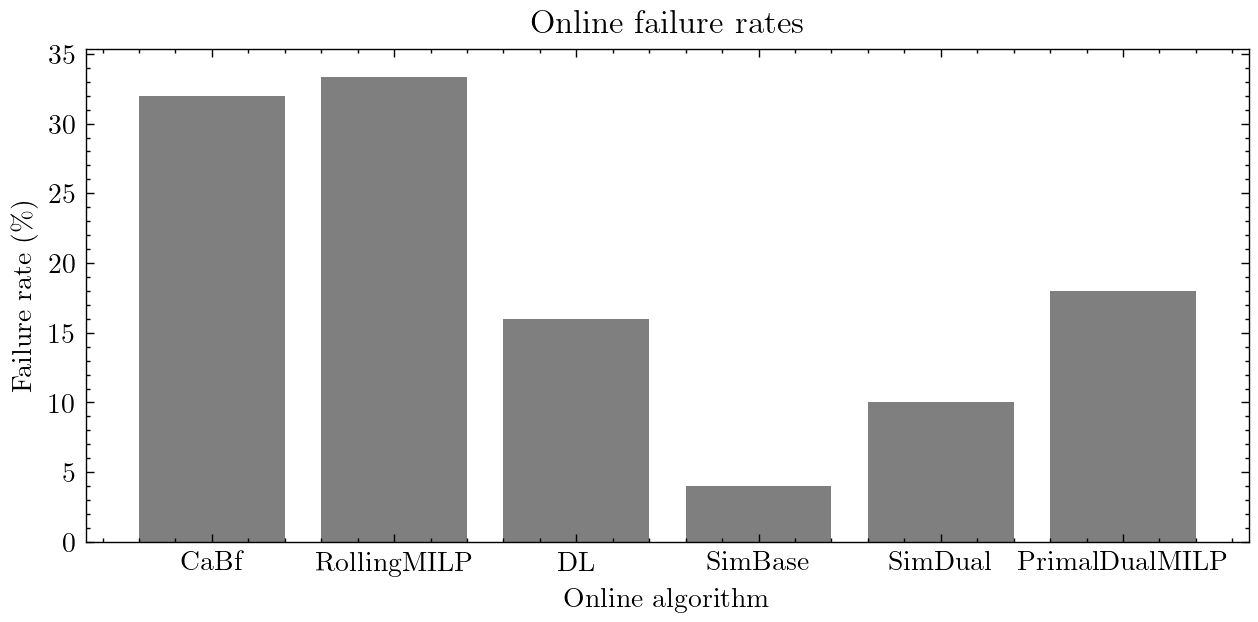

In [60]:
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    df_online_seed = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    if not df_online_seed.empty:
        df_online_seed["failed"] = (
            df_online_seed["offline_status"].isin(offline_fail_statuses)
            | df_online_seed["online_status"].isin(online_fail_statuses)
        )

        grouped = (
            df_online_seed.groupby(["online_short"], dropna=False)
            .agg(fail_rate=("failed", "mean"), run_count=("failed", "size"))
            .reset_index()
        )

        online_order = ["CaBf", "RollingMILP", "DL", "SimBase","SimDual", "PrimalDualMILP"]
        grouped["online_short"] = pd.Categorical(
            grouped["online_short"], categories=online_order, ordered=True
        )
        grouped = grouped.sort_values("online_short")
        grouped = grouped[grouped["online_short"].notna()]

        fig, ax = plt.subplots(figsize=(7.5, 3.2))
        ax.bar(
            grouped["online_short"].astype(str),
            grouped["fail_rate"] * 100.0,
            color="tab:gray",
        )

        ax.set_title("Online failure rates")
        ax.set_xlabel("Online algorithm")
        ax.set_ylabel("Failure rate (\%)")

        y_max = (grouped["fail_rate"].max() or 0) * 100.0
        y_pad = 2 if y_max > 0 else 5
        ax.set_ylim(0, y_max + y_pad)


In [61]:
if df_per_seed is not None:
    offline_fail_statuses = {"INFEASIBLE", "INF_OR_UNBD", "UNBOUNDED"}
    online_fail_statuses = {"INFEASIBLE"}

    df_online_seed = df_per_seed[(df_per_seed["kind"] == "eval") & (df_per_seed["M_off"] == 0)].copy()
    if not df_online_seed.empty:
        df_online_seed["failed"] = (
            df_online_seed["offline_status"].isin(offline_fail_statuses)
            | df_online_seed["online_status"].isin(online_fail_statuses)
        )

        status_counts = (
            df_online_seed.groupby(["online_short", "online_status"], dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values(["online_short", "count"], ascending=[True, False])
        )
        display(status_counts)

        failure_rates = (
            df_online_seed.groupby("online_short")["failed"]
            .agg(fail_rate="mean", total_runs="size")
            .reset_index()
            .sort_values("fail_rate", ascending=False)
        )
        display(failure_rates)

        scenario_failures = (
            df_online_seed[df_online_seed["failed"]]
            .groupby(["online_short", "scenario"], dropna=False)
            .size()
            .reset_index(name="fail_count")
            .sort_values("fail_count", ascending=False)
        )
        display(scenario_failures.head(20))


,online_short,online_status,count
0,CaBf,COMPLETED,204
1,CaBf,INFEASIBLE,96
2,DL,COMPLETED,252
3,DL,INFEASIBLE,48
4,PrimalDualMILP,COMPLETED,246
5,PrimalDualMILP,INFEASIBLE,54
6,RollingMILP,COMPLETED,200
7,RollingMILP,INFEASIBLE,100
8,SimBase,COMPLETED,288
9,SimBase,INFEASIBLE,12


,online_short,fail_rate,total_runs
3,RollingMILP,0.333333,300
0,CaBf,0.320000,300
2,PrimalDualMILP,0.180000,300
1,DL,0.160000,300
5,SimDual,0.100000,150
4,SimBase,0.040000,300


,online_short,scenario,fail_count
3,RollingMILP,baseline_midvar_off0_on100,100
0,CaBf,baseline_midvar_off0_on100,96
2,PrimalDualMILP,baseline_midvar_off0_on100,54
1,DL,baseline_midvar_off0_on100,48
5,SimDual,baseline_midvar_off0_on100,15
4,SimBase,baseline_midvar_off0_on100,12


In [62]:
if df_eval is not None and df_opt is not None:
    df_opt_key = df_opt[["sweep", "run_id", "scenario", "total_objective_mean"]].rename(
        columns={"total_objective_mean": "optimal_objective_mean"}
    )
    df_ratio_base_all = df_eval.merge(df_opt_key, on=["sweep", "run_id", "scenario"], how="left")
    df_ratio_base_all = df_ratio_base_all.copy()
    df_ratio_base_all["competitive_ratio"] = (
        df_ratio_base_all["total_objective_mean"] / df_ratio_base_all["optimal_objective_mean"]
    )

    df_baseline = df_ratio_base_all[df_ratio_base_all["family"] == "baseline"].copy()

    denom = df_baseline["M_off"].fillna(0) + df_baseline["M_on"].fillna(0)
    df_baseline["offline_pct"] = (
        (df_baseline["M_off"] / denom) * 100
    ).where(denom > 0)

    df_baseline["total_failures"] = (
        df_baseline["offline_failures"].fillna(0) + df_baseline["online_failures"].fillna(0)
    )
    df_baseline["seed_count"] = df_baseline["seed_count"].fillna(0)

    grouped = (
        df_baseline.groupby(["offline_pct", "offline_short", "online_short"], dropna=False)
        .agg(
            expected_cr=("competitive_ratio", "mean"),
            failure_count=("total_failures", "sum"),
            seed_count=("seed_count", "sum"),
        )
        .reset_index()
    )

    grouped["failure_rate"] = grouped["failure_count"] / grouped["seed_count"].replace(
        {0: pd.NA}
    )

    df_baseline_expected = grouped.rename(
        columns={
            "offline_short": "offline_algorithm",
            "online_short": "online_algorithm",
        }
    )[[
        "offline_pct",
        "offline_algorithm",
        "online_algorithm",
        "expected_cr",
        "failure_rate",
    ]]
    df_baseline_expected["offline_pct"] = df_baseline_expected["offline_pct"].round(0).astype("Int64")
else:
    df_baseline_expected = None



In [63]:
df_baseline_expected.head(20)

,offline_pct,offline_algorithm,online_algorithm,expected_cr,failure_rate
0,0,CaBfd,CaBf,1.007516,0.32
1,0,CaBfd,DL,1.008479,0.16
2,0,CaBfd,PrimalDualMILP,1.004454,0.18
3,0,CaBfd,RollingMILP,1.003541,0.32
4,0,CaBfd,SimBase,0.998765,0.04
5,0,CaBfd,SimDual,0.998997,0.10
6,0,MILP,CaBf,1.007516,0.32
7,0,MILP,DL,1.008479,0.16
8,0,MILP,PrimalDualMILP,1.004454,0.18
9,0,MILP,RollingMILP,1.005146,0.30


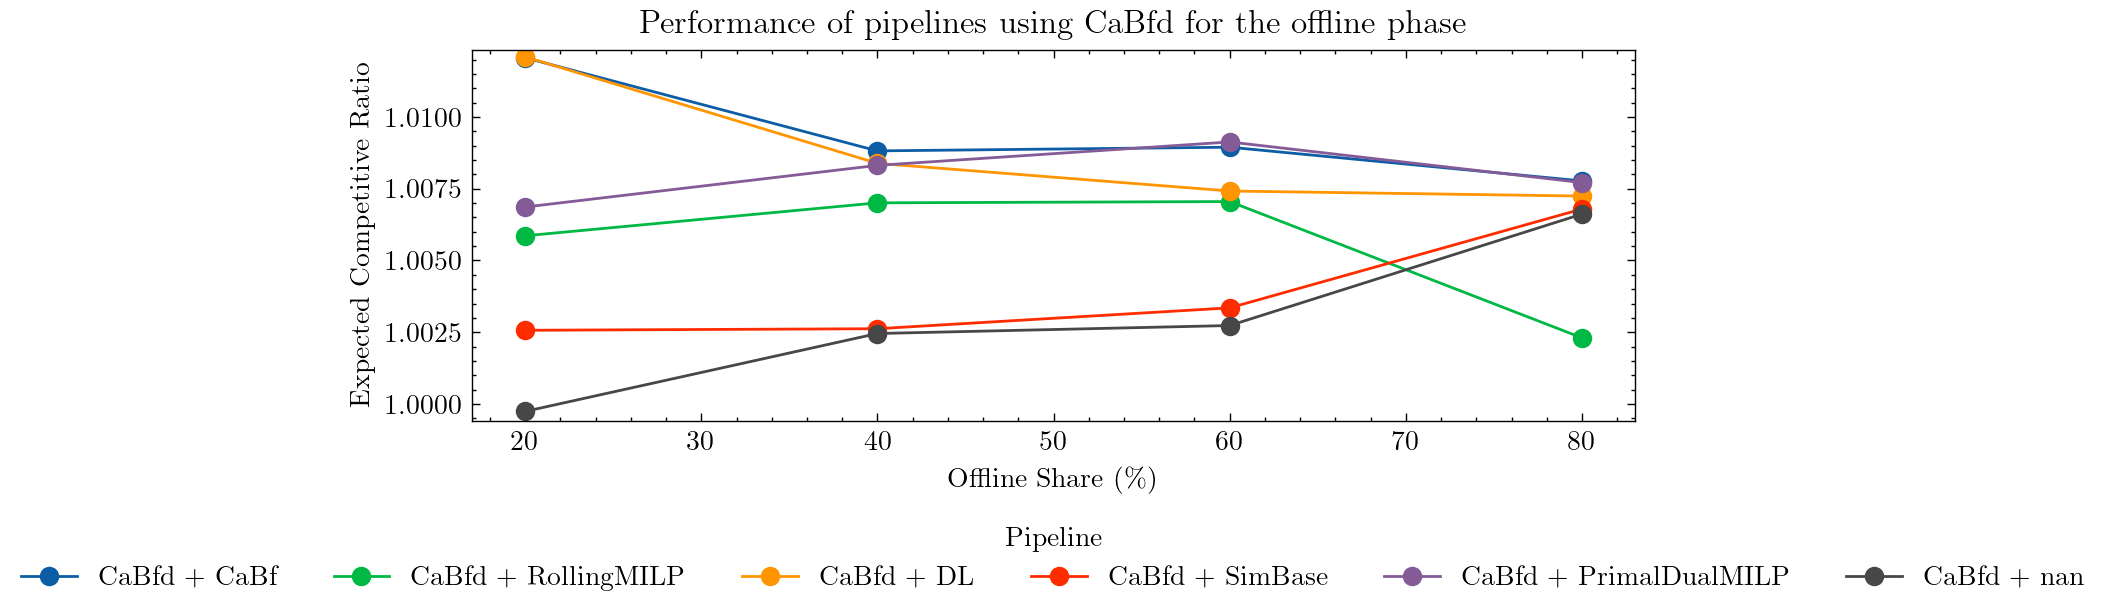

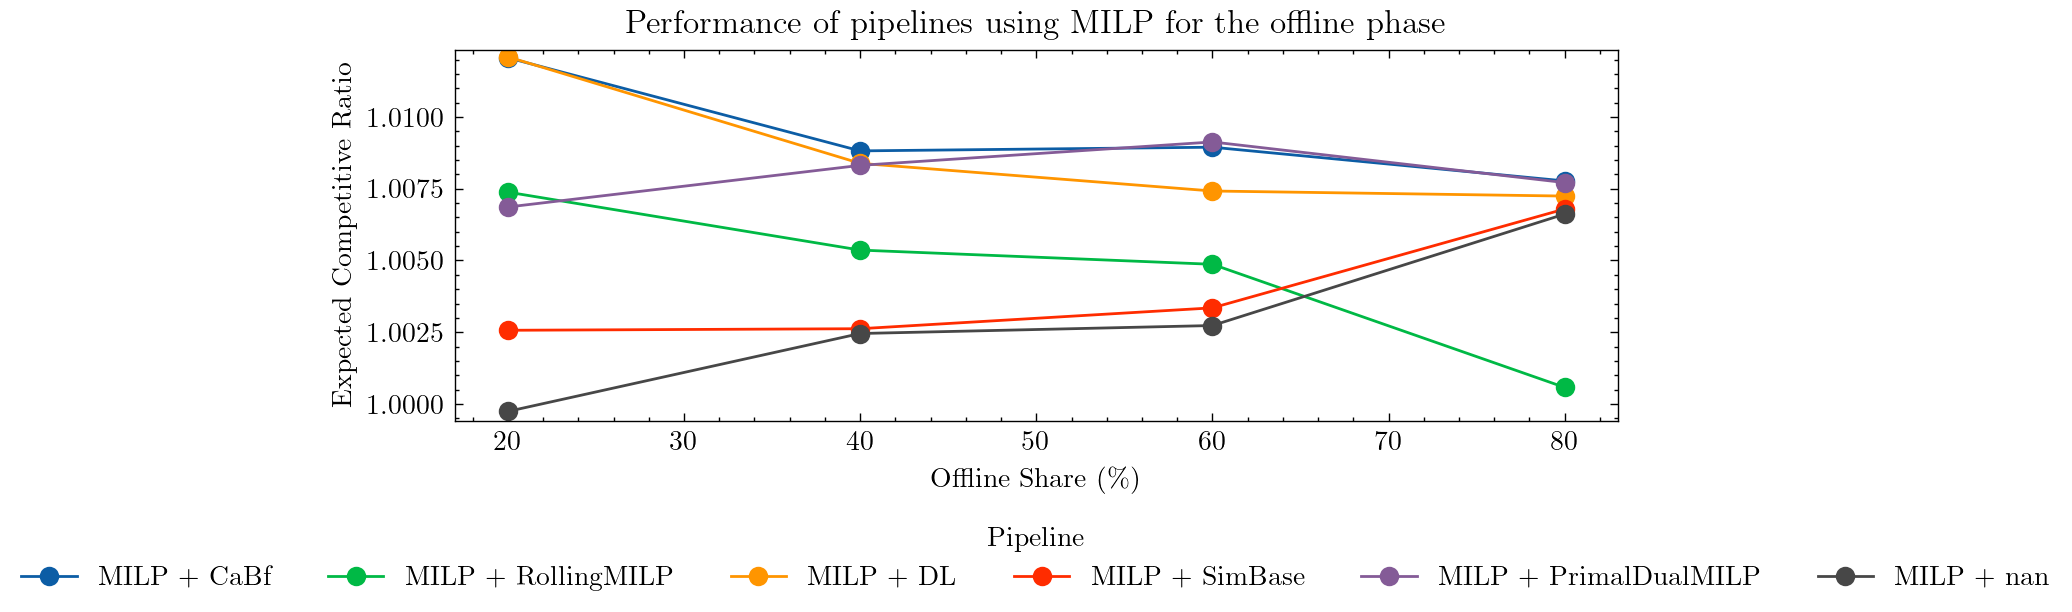

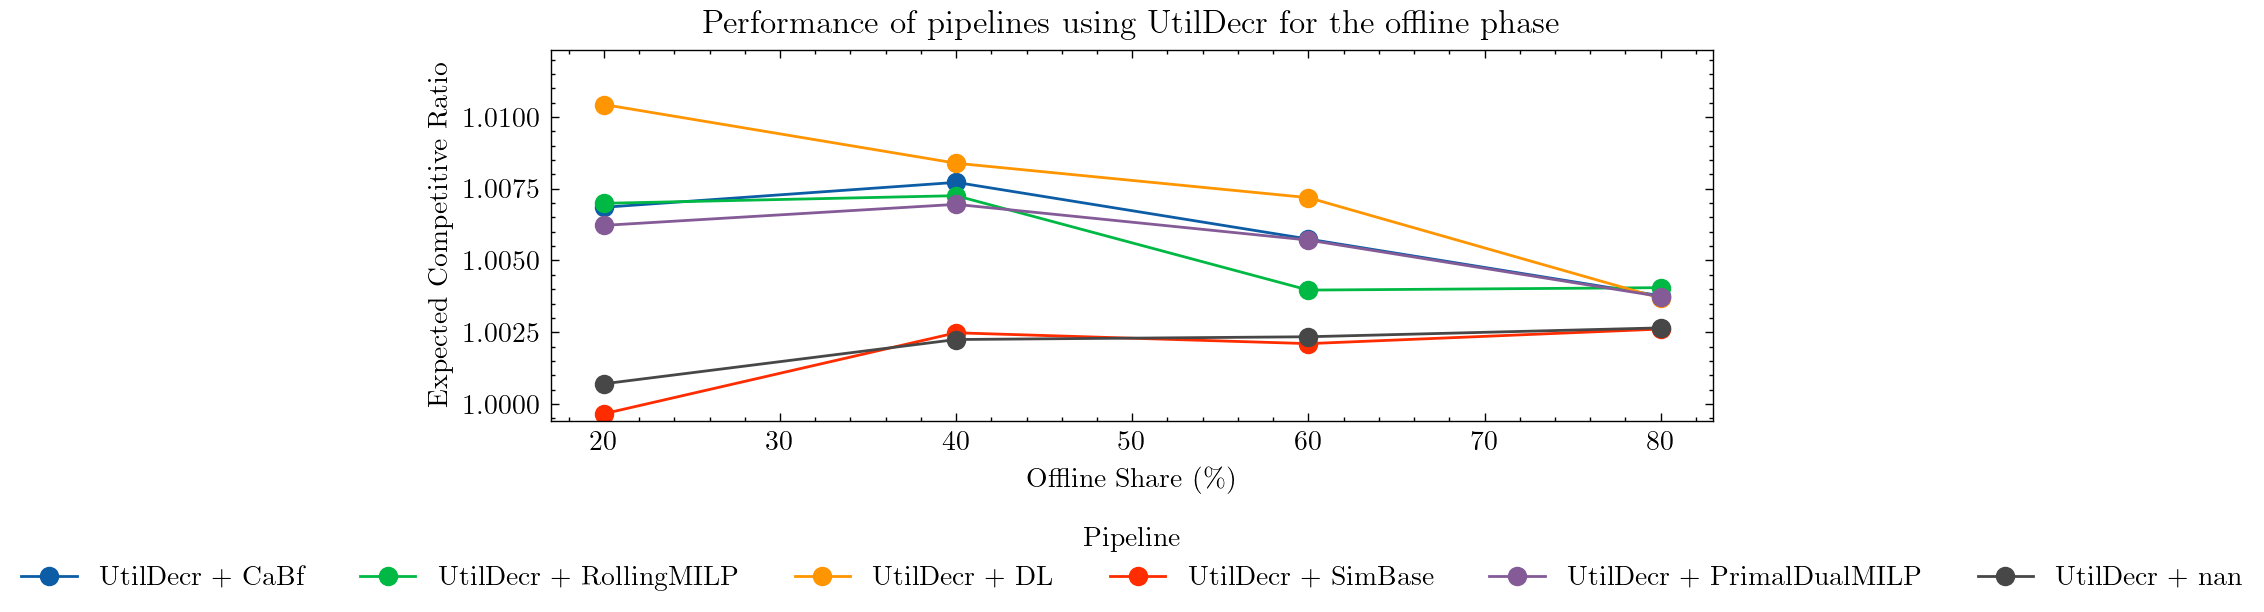

In [64]:
if df_baseline_expected is not None:
    df_plot = df_baseline_expected[
        df_baseline_expected["offline_pct"].gt(0).fillna(False)
    ].copy()

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    online_order = ["CaBf", "RollingMILP","DL", "SimBase", "PrimalDualMILP"]

    df_plot["offline_algorithm"] = pd.Categorical(
        df_plot["offline_algorithm"], categories=offline_order, ordered=True
    )
    df_plot["online_algorithm"] = pd.Categorical(
        df_plot["online_algorithm"], categories=online_order, ordered=True
    )
    df_plot = df_plot.sort_values(
        ["offline_algorithm", "online_algorithm", "offline_pct"]
    )

    y_min = df_plot["expected_cr"].min()
    y_max = df_plot["expected_cr"].max()
    if pd.isna(y_min) or pd.isna(y_max):
        y_min, y_max = 0.0, 1.0
    y_pad = 0.02 * (y_max - y_min) if y_max > y_min else 0.02 * max(1.0, abs(y_max))

    for offline in offline_order:
        df_sub = df_plot[df_plot["offline_algorithm"] == offline].copy()
        if df_sub.empty:
            continue

        df_sub["pipeline"] = (
            df_sub["offline_algorithm"].astype(str)
            + " + "
            + df_sub["online_algorithm"].astype(str)
        )

        fig, ax = plt.subplots(figsize=(7.5, 3.2))
        for pipeline, df_pipe in df_sub.groupby("pipeline", sort=False):
            ax.plot(
                df_pipe["offline_pct"],
                df_pipe["expected_cr"],
                marker="o",
                label=pipeline,
            )

        ax.set_title(f"Performance of pipelines using {offline} for the offline phase")
        ax.set_xlabel(r"Offline Share (\%)")
        ax.set_ylabel("Expected Competitive Ratio")
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ncol = max(1, df_sub["pipeline"].nunique())
        ax.legend(
            title="Pipeline",
            ncol=ncol,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.22),
        )
        fig.subplots_adjust(bottom=0.3)


In [65]:
if df_baseline_expected is not None:
    df_fail = df_baseline_expected[
        df_baseline_expected["offline_pct"].gt(0).fillna(False)
    ].copy()
    df_fail["pipeline"] = (
        df_fail["offline_algorithm"].astype(str)
        + " + "
        + df_fail["online_algorithm"].astype(str)
    )

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    online_order = ["CaBf", "RollingMILP", "DL", "SimBase", "PrimalDualMILP"]
    pipeline_order = [f"{off} + {on}" for off in offline_order for on in online_order]

    df_fail_tbl = (
        df_fail.pivot_table(
            index="offline_pct",
            columns="pipeline",
            values="failure_rate",
            aggfunc="mean",
        )
        .reindex(columns=pipeline_order)
        .sort_index()
    )
    df_fail_tbl = (df_fail_tbl * 100.0).round(2)
    df_fail_tbl.index.name = r"Offline share (\%)"
    display(df_fail_tbl)


pipeline,CaBfd + CaBf,CaBfd + RollingMILP,CaBfd + DL,CaBfd + SimBase,CaBfd + PrimalDualMILP,MILP + CaBf,MILP + RollingMILP,MILP + DL,MILP + SimBase,MILP + PrimalDualMILP,UtilDecr + CaBf,UtilDecr + RollingMILP,UtilDecr + DL,UtilDecr + SimBase,UtilDecr + PrimalDualMILP
Offline share (\%),,,,,,,,,,,,,,,
20,16.0,40.0,10.0,10.0,32.0,16.0,36.0,10.0,10.0,32.0,28.0,42.0,14.0,14.0,28.0
40,28.0,44.0,22.0,10.0,28.0,28.0,48.0,22.0,10.0,28.0,26.0,30.0,20.0,10.0,26.0
60,22.0,50.0,20.0,6.0,20.0,22.0,44.0,20.0,6.0,20.0,18.0,28.0,10.0,4.0,18.0
80,26.0,72.0,20.0,10.0,26.0,26.0,72.0,20.0,10.0,26.0,6.0,18.0,6.0,8.0,6.0


## LaTeX tables


In [66]:
# df_tbl vorbereiten wie gehabt
df_tbl = df_baseline_expected[
    df_baseline_expected["offline_pct"].gt(0).fillna(False)
].copy()
df_tbl = df_tbl.pivot_table(
    index="offline_pct",
    columns=["offline_algorithm", "online_algorithm"],
    values="expected_cr",
    aggfunc="mean",
).sort_index()

df_tbl.index.name = r"Offline share (\%)"

offline_order = ["CaBfd", "MILP", "UtilDecr"]
latex_blocks = {}

for offline in offline_order:
    sub = df_tbl.xs(offline, level=0, axis=1)
    sub.columns.name = "Online algorithm"
    latex_blocks[offline] = sub.to_latex(
        float_format="%.3f",
        escape=True,
        column_format="lccc",
        caption=f"Expected competitive ratio ({offline})",
        label=f"tab:expected_cr_{offline.lower()}",
        bold_rows=True,
    )

# Ausgabe (oder print einzeln)
for k, v in latex_blocks.items():
    print(v)
    print("\n")


\begin{table}
\caption{Expected competitive ratio (CaBfd)}
\label{tab:expected_cr_cabfd}
\begin{tabular}{lccc}
\toprule
Online algorithm & CaBf & DL & PrimalDualMILP & RollingMILP & SimBase & SimDual \\
Offline share (\%) &  &  &  &  &  &  \\
\midrule
\textbf{20} & 1.012 & 1.012 & 1.007 & 1.006 & 1.003 & 1.000 \\
\textbf{40} & 1.009 & 1.008 & 1.008 & 1.007 & 1.003 & 1.002 \\
\textbf{60} & 1.009 & 1.007 & 1.009 & 1.007 & 1.003 & 1.003 \\
\textbf{80} & 1.008 & 1.007 & 1.008 & 1.002 & 1.007 & 1.007 \\
\bottomrule
\end{tabular}
\end{table}



\begin{table}
\caption{Expected competitive ratio (MILP)}
\label{tab:expected_cr_milp}
\begin{tabular}{lccc}
\toprule
Online algorithm & CaBf & DL & PrimalDualMILP & RollingMILP & SimBase & SimDual \\
Offline share (\%) &  &  &  &  &  &  \\
\midrule
\textbf{20} & 1.012 & 1.012 & 1.007 & 1.007 & 1.003 & 1.000 \\
\textbf{40} & 1.009 & 1.008 & 1.008 & 1.005 & 1.003 & 1.002 \\
\textbf{60} & 1.009 & 1.007 & 1.009 & 1.005 & 1.003 & 1.003 \\
\textbf{80} & 1.